In [1]:
import sys
import warnings

sys.path.append("/home/jovyan/projects/mjosa_water_temp/code")
sys.path.append("/home/jovyan/development/nivapy3/nivapy3")

import glob
import os
import time
from urllib.error import URLError

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import nivapy3 as nivapy
import pandas as pd
import requests
import stats
import utils
from xyzservices import TileProvider

warnings.simplefilter("ignore")
plt.style.use("ggplot")

In [2]:
# Monkey-patch requests to avoid Vann-nett SSL error
_original_request = requests.Session.request


def _patched_request(self, method, url, **kwargs):
    kwargs.setdefault("verify", False)
    return _original_request(self, method, url, **kwargs)


requests.Session.request = _patched_request

In [3]:
# Define provider for Kartverket basemaps
kartverket = TileProvider(
    name="Kartverket",
    url="https://cache.kartverket.no/v1/wmts/1.0.0/topo/default/webmercator/{z}/{y}/{x}.png",
    attribution="© Kartverket"
)

# TEOTIL3 for Lillestrøm kommune
# Notebook 02: Data from Vannmiljø, Vann-Nett and NVE

Jan Erik Bøgeberg and Kristian Moseby have proposed monitoring sites in Vannmiljø for the main catchments of interest around Lillestrøm Kommune. This notebook downloads data from Vannmiljø and Vann-Nett for these areas. It also estimates daily discharge using NVE's Grid Time Series API.

## 1. Sites and waterbodies of interest

See e-mail from Jan Erik received 24.02.2026.

In [4]:
# Read site data
xl_path = r"../data/lillestrom_monitoring_sites.xlsx"
stn_df = pd.read_excel(xl_path, sheet_name="chem_stns")
stn_df

,catchment,station_id,station_name,regine,wb_id,wb_name,lon,lat,comment
0,Sagelva,002-46599,Sagelva ved Skjetten bro (F3),002.CBA0,002-3899-R,Fjellhamarelva - Sagelva,11.01695,59.95850,Downstream
1,Sagelva,002-63540,Fjellhammarelva (F10),002.CBA0,002-3899-R,Fjellhamarelva - Sagelva,10.99617,59.94419,Slightly upstream
2,Nitelva,002-30586,Rud Nitelva (N8 ),002.CB0,002-3891-R,Nedre Nitelva,11.05700,59.94553,Downstream
3,Nitelva,002-30578,Kjellerholen Nitelva (N6),002.CC0,002-1638-R,Nitelva Slattum-Kjeller,11.00850,59.97925,Slightly upstream
4,Leira,002-29659,Leira ved Borgen bru (L5),002.CAA0,002-3384-R,Leira nedstrøms Krokfoss,11.10032,59.95036,Downstream
5,Leira,002-30584,Leira ved Leirsund (L8),002.CAA0,002-3384-R,Leira nedstrøms Krokfoss,11.08849,59.99755,Slightly upstream
6,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,002.D2Z,002-3659-R,Rømua,11.22099,60.02163,Downstream
7,Jeksla,002-30593,"Jeksla ved Haugli, J14",002.CAA0,002-599-R,Jeksla,11.10637,60.00199,Downstream. Small part of regine
8,Åa,002-60929,Fossåa ved Sylta (ÅA1),002.D3Z,002-3685-R,Fossåa,11.30018,59.99209,Downstream
9,Åa,002-60963,Sloråa ved Bruvollen (ÅA3),002.D3Z,002-3687-R,Sloråa,11.34807,59.98512,Upstream. North branch


## 2. Data from Vannmiljø

### 2.1. data for sites

The code below gets data for each site suggested by Jan Erik and Kristian.

In [5]:
# Pars of interest
vm_par_list = [
    "N-TOT",
    "N-NO3",
    "N-NH4",
    "P-TOT",
    "P-PO4",
    "P-ORTO",
    "TOC",
    "STS",
]

In [6]:
# Query Vannmiljø
data = {
    "FromRegDate": "1900-01-01",
    "WaterLocationCodeFilter": stn_df["station_id"].tolist(),
}
wc_df = nivapy.da.post_data_to_vannmiljo("GetRegistrations", data=data)

# Tidy to cols of interest
names_dict = {
    "WaterLocationID": "station_id",
    "WaterLocationCode": "station_code",
    "Name": "station_name",
    "WaterCategory": "category",
    "CoordX": "utm33_east",
    "CoordY": "utm33_north",
    "FylkeID": "fylke_id",
    "Fylke": "fylke_name",
    "KommuneID": "kommune_id",
    "Kommune": "kommune_name",
    "VassdragsomradeID": "vassom_id",
    "Vassdragsomrade": "vassom_name",
    "VannomradeID": "vannom_id",
    "Vannomrade": "vannom_name",
    "VannregionID": "vannreg_id",
    "Vannregion": "vannreg_name",
    "WaterBodyID": "waterbody_id",
    "WaterBody": "waterbody_name",
    "FeatureType": "feature_type",
    "ActivityID": "activity_id",
    "ActivityName": "activity_name",
    "Employer": "employer",
    "Contractor": "contractor",
    "MediumName": "medium_name",
    "SamplingTime": "sample_date",
    "UpperDepth": "upper_depth",
    "LowerDepth": "lower_depth",
    "FilteredSample": "filtered",
    "ParameterID": "par_id",
    "ParameterName": "par_name",
    "ValueOperator": "flag",
    "RegValue": "value",
    "Unit": "unit",
    "DetectionLimit": "lod",
    "QuantificationLimit": "loq",
}
stn_cols = [
    "station_id",
    "station_code",
    "station_name",
    "feature_type",
    "category",
    "fylke_id",
    "fylke_name",
    "kommune_id",
    "kommune_name",
    "vassom_id",
    "vassom_name",
    "vannom_id",
    "vannom_name",
    "vannreg_id",
    "vannreg_name",
    "waterbody_id",
    "waterbody_name",
    "utm33_east",
    "utm33_north",
]
wc_df = wc_df[names_dict.keys()].rename(columns=names_dict)
wc_df = wc_df.query("medium_name == 'Ferskvann'")
wc_df = wc_df.query("par_id in @vm_par_list")
wc_df["sample_date"] = pd.to_datetime(wc_df["sample_date"])
vm_stn_df = (
    wc_df[stn_cols].drop_duplicates(subset="station_code").reset_index(drop=True)
)
vm_stn_gdf = gpd.GeoDataFrame(
    vm_stn_df,
    geometry=gpd.points_from_xy(
        vm_stn_df["utm33_east"], vm_stn_df["utm33_north"], crs="epsg:25833"
    ),
)

# Prepare to convert to wide
wc_df_wide = wc_df.copy()
wc_df_wide["filtered"] = wc_df_wide["filtered"].map({True: "Filt", False: "Ufilt"})
wc_df_wide["par_unit"] = (
    wc_df_wide["par_id"]
    + "_"
    + wc_df_wide["filtered"].astype(str)
    + "_"
    + wc_df_wide["unit"]
)
wc_df_wide = wc_df_wide.drop(
    columns=["par_id", "par_name", "flag", "unit", "filtered", "lod", "loq"]
)
wc_df_wide["upper_depth"] = wc_df_wide["upper_depth"].fillna(0)
wc_df_wide["lower_depth"] = wc_df_wide["lower_depth"].fillna(0)
wc_df_wide = wc_df_wide.dropna(subset="value").fillna("none")
id_cols = [col for col in wc_df_wide.columns if col != "value"]

# Save duplicated values for checking
dup_df = wc_df_wide[wc_df_wide.duplicated(subset=id_cols, keep=False)].sort_values(
    id_cols
)
if len(dup_df) > 0:
    print(
        "The dataset contains duplicates. These will be saved for checking and then averaged."
    )
    dup_xlsx = r"../data/vannmiljo_duplicates_stations.xlsx"
    dup_df.to_excel(dup_xlsx, index=False)

    # Average duplicates
    wc_df_wide = wc_df_wide.groupby(id_cols).mean().reset_index()

# Convert to wide
wc_df_wide = wc_df_wide.set_index(id_cols).unstack("par_unit")
wc_df_wide.columns = wc_df_wide.columns.get_level_values(1)
wc_df_wide = wc_df_wide.reset_index()

# Tidy pars
# Some labs report NO3 as filtered and others as unfiltered, but these are dissolved, so it doesn't matter
wc_df_wide["NO3_µg/l"] = wc_df_wide["N-NO3_Ufilt_µg/l N"].fillna(
    wc_df_wide["N-NO3_Filt_µg/l N"]
)
wc_df_wide = wc_df_wide.drop(
    columns=[
        "N-NO3_Ufilt_µg/l N",
        "N-NO3_Filt_µg/l N",
    ]
)
wc_df_wide = wc_df_wide.rename(
    columns={
        "N-TOT_Ufilt_µg/l N": "TOTN_µg/l",
        "N-NH4_Ufilt_µg/l N": "NH4_µg/l",
        "P-ORTO_Filt_µg/l P": "SRP_µg/l",
        "P-ORTO_Ufilt_µg/l P": "TRP_µg/l",
        "P-PO4_Filt_µg/l P": "DIP_µg/l",
        "P-PO4_Ufilt_µg/l P": "TIP_µg/l",
        "P-TOT_Filt_µg/l P": "TDP_µg/l",
        "P-TOT_Ufilt_µg/l P": "TOTP_µg/l",
        "STS_Ufilt_mg/l": "SS_mg/l",
        "TOC_Ufilt_mg/l C": "TOC_mg/l",
    }
)

# Save
vm_xl_path = r"../data/vannmiljo_data_stations.xlsx"
with pd.ExcelWriter(vm_xl_path) as writer:
    vm_stn_df.to_excel(writer, sheet_name="vm_stations", index=False)
    wc_df.to_excel(writer, sheet_name="data_long", index=False)
    wc_df_wide.to_excel(writer, sheet_name="data_wide", index=False)

wc_df_wide.head()

The dataset contains duplicates. These will be saved for checking and then averaged.


par_unit,station_id,station_code,station_name,category,utm33_east,utm33_north,fylke_id,fylke_name,kommune_id,kommune_name,...,TOTN_µg/l,SRP_µg/l,TRP_µg/l,DIP_µg/l,TIP_µg/l,TDP_µg/l,TOTP_µg/l,SS_mg/l,TOC_mg/l,NO3_µg/l
0,28960,002-28960,Rømua ved Lørenfallet - RØM1,R,289429.5,6659838.3,32,Akershus,3205,Lillestrøm,...,1790.0,NaN,NaN,16.0,NaN,NaN,54.0,22.0,7.7,NaN
1,28960,002-28960,Rømua ved Lørenfallet - RØM1,R,289429.5,6659838.3,32,Akershus,3205,Lillestrøm,...,1080.0,NaN,NaN,8.0,NaN,NaN,34.0,6.8,5.9,NaN
2,28960,002-28960,Rømua ved Lørenfallet - RØM1,R,289429.5,6659838.3,32,Akershus,3205,Lillestrøm,...,1430.0,NaN,NaN,6.0,NaN,NaN,34.0,14.0,4.2,NaN
3,28960,002-28960,Rømua ved Lørenfallet - RØM1,R,289429.5,6659838.3,32,Akershus,3205,Lillestrøm,...,1100.0,NaN,NaN,1.0,NaN,NaN,40.0,10.0,4.5,NaN
4,28960,002-28960,Rømua ved Lørenfallet - RØM1,R,289429.5,6659838.3,32,Akershus,3205,Lillestrøm,...,2260.0,NaN,NaN,2.0,NaN,NaN,65.0,24.0,4.7,NaN


### 2.3. Data for waterbodies

Waterbody status is often determined using data from several sites. Using the Vannmiljø API, it is possible to get all data used for each waterbody, rather than just for specific sites. The code below gets data for all sites associated with the waterbody IDs in `stn_df`.

In [7]:
# Query Vannmiljø
data = {
    "FromRegDate": "1900-01-01",
    "WaterBodyIDFilter": stn_df["wb_id"].unique().tolist(),
}
wc_df = nivapy.da.post_data_to_vannmiljo("GetRegistrations", data=data)

# Tidy to cols of interest
names_dict = {
    "WaterLocationID": "station_id",
    "WaterLocationCode": "station_code",
    "Name": "station_name",
    "WaterCategory": "category",
    "CoordX": "utm33_east",
    "CoordY": "utm33_north",
    "FylkeID": "fylke_id",
    "Fylke": "fylke_name",
    "KommuneID": "kommune_id",
    "Kommune": "kommune_name",
    "VassdragsomradeID": "vassom_id",
    "Vassdragsomrade": "vassom_name",
    "VannomradeID": "vannom_id",
    "Vannomrade": "vannom_name",
    "VannregionID": "vannreg_id",
    "Vannregion": "vannreg_name",
    "WaterBodyID": "waterbody_id",
    "WaterBody": "waterbody_name",
    "FeatureType": "feature_type",
    "ActivityID": "activity_id",
    "ActivityName": "activity_name",
    "Employer": "employer",
    "Contractor": "contractor",
    "MediumName": "medium_name",
    "SamplingTime": "sample_date",
    "UpperDepth": "upper_depth",
    "LowerDepth": "lower_depth",
    "FilteredSample": "filtered",
    "ParameterID": "par_id",
    "ParameterName": "par_name",
    "ValueOperator": "flag",
    "RegValue": "value",
    "Unit": "unit",
    "DetectionLimit": "lod",
    "QuantificationLimit": "loq",
}
stn_cols = [
    "station_id",
    "station_code",
    "station_name",
    "feature_type",
    "category",
    "fylke_id",
    "fylke_name",
    "kommune_id",
    "kommune_name",
    "vassom_id",
    "vassom_name",
    "vannom_id",
    "vannom_name",
    "vannreg_id",
    "vannreg_name",
    "waterbody_id",
    "waterbody_name",
    "utm33_east",
    "utm33_north",
]
wc_df = wc_df[names_dict.keys()].rename(columns=names_dict)
wc_df = wc_df.query("medium_name == 'Ferskvann'")
wc_df = wc_df.query("par_id in @vm_par_list")
wc_df["sample_date"] = pd.to_datetime(wc_df["sample_date"])
vm_stn_df = (
    wc_df[stn_cols].drop_duplicates(subset="station_code").reset_index(drop=True)
)
vm_stn_gdf = gpd.GeoDataFrame(
    vm_stn_df,
    geometry=gpd.points_from_xy(
        vm_stn_df["utm33_east"], vm_stn_df["utm33_north"], crs="epsg:25833"
    ),
)

# Prepare to convert to wide
wc_df_wide = wc_df.copy()
wc_df_wide["filtered"] = wc_df_wide["filtered"].map({True: "Filt", False: "Ufilt"})
wc_df_wide["par_unit"] = (
    wc_df_wide["par_id"]
    + "_"
    + wc_df_wide["filtered"].astype(str)
    + "_"
    + wc_df_wide["unit"]
)
wc_df_wide = wc_df_wide.drop(
    columns=["par_id", "par_name", "flag", "unit", "filtered", "lod", "loq"]
)
wc_df_wide["upper_depth"] = wc_df_wide["upper_depth"].fillna(0)
wc_df_wide["lower_depth"] = wc_df_wide["lower_depth"].fillna(0)
wc_df_wide = wc_df_wide.dropna(subset="value").fillna("none")
id_cols = [col for col in wc_df_wide.columns if col != "value"]

# Save duplicated values for checking
dup_df = wc_df_wide[wc_df_wide.duplicated(subset=id_cols, keep=False)].sort_values(
    id_cols
)
if len(dup_df) > 0:
    print(
        "The dataset contains duplicates. These will be saved for checking and then averaged."
    )
    dup_xlsx = r"../data/vannmiljo_duplicates_waterbodies.xlsx"
    dup_df.to_excel(dup_xlsx, index=False)

    # Average duplicates
    wc_df_wide = wc_df_wide.groupby(id_cols).mean().reset_index()

# Convert to wide
wc_df_wide = wc_df_wide.set_index(id_cols).unstack("par_unit")
wc_df_wide.columns = wc_df_wide.columns.get_level_values(1)
wc_df_wide = wc_df_wide.reset_index()

# Tidy pars
# Some labs report NO3 as filtered and others as unfiltered, but these are dissolved, so it doesn't matter
wc_df_wide["NO3_µg/l"] = wc_df_wide["N-NO3_Ufilt_µg/l N"].fillna(
    wc_df_wide["N-NO3_Filt_µg/l N"]
)
wc_df_wide = wc_df_wide.drop(
    columns=[
        "N-NO3_Ufilt_µg/l N",
        "N-NO3_Filt_µg/l N",
    ]
)
wc_df_wide = wc_df_wide.rename(
    columns={
        "N-TOT_Ufilt_µg/l N": "TOTN_µg/l",
        "N-NH4_Ufilt_µg/l N": "NH4_µg/l",
        "P-ORTO_Filt_µg/l P": "SRP_µg/l",
        "P-ORTO_Ufilt_µg/l P": "TRP_µg/l",
        "P-PO4_Filt_µg/l P": "DIP_µg/l",
        "P-PO4_Ufilt_µg/l P": "TIP_µg/l",
        "P-TOT_Filt_µg/l P": "TDP_µg/l",
        "P-TOT_Ufilt_µg/l P": "TOTP_µg/l",
        "STS_Ufilt_mg/l": "SS_mg/l",
        "TOC_Ufilt_mg/l C": "TOC_mg/l",
    }
)

# Save
vm_xl_path = r"../data/vannmiljo_data_waterbodies.xlsx"
with pd.ExcelWriter(vm_xl_path) as writer:
    vm_stn_df.to_excel(writer, sheet_name="vm_stations", index=False)
    wc_df.to_excel(writer, sheet_name="data_long", index=False)
    wc_df_wide.to_excel(writer, sheet_name="data_wide", index=False)

wc_df_wide.head()

The dataset contains duplicates. These will be saved for checking and then averaged.


par_unit,station_id,station_code,station_name,category,utm33_east,utm33_north,fylke_id,fylke_name,kommune_id,kommune_name,...,TOTN_µg/l,SRP_µg/l,TRP_µg/l,DIP_µg/l,TIP_µg/l,TDP_µg/l,TOTP_µg/l,SS_mg/l,TOC_mg/l,NO3_µg/l
0,28251,002-28251,Nitelva ved Åmot,R,280231.9011,6.651353e+06,32,Akershus,3205,Lillestrøm,...,2600.0,NaN,NaN,NaN,NaN,NaN,92.0,NaN,NaN,1550.0
1,28251,002-28251,Nitelva ved Åmot,R,280231.9011,6.651353e+06,32,Akershus,3205,Lillestrøm,...,1275.0,NaN,NaN,NaN,NaN,NaN,80.0,NaN,NaN,NaN
2,28251,002-28251,Nitelva ved Åmot,R,280231.9011,6.651353e+06,32,Akershus,3205,Lillestrøm,...,NaN,NaN,NaN,NaN,NaN,NaN,88.0,NaN,NaN,NaN
3,28251,002-28251,Nitelva ved Åmot,R,280231.9011,6.651353e+06,32,Akershus,3205,Lillestrøm,...,2150.0,NaN,NaN,NaN,NaN,NaN,108.0,NaN,NaN,640.0
4,28251,002-28251,Nitelva ved Åmot,R,280231.9011,6.651353e+06,32,Akershus,3205,Lillestrøm,...,2300.0,NaN,NaN,NaN,NaN,NaN,93.0,NaN,NaN,1250.0


## 3. Data from Vann-nett

In [8]:
# Quality elements of interest
vn_par_list = [
    "Total nitrogen",
    "Ammonia",
    "Total oxidised Nitrogen",
    "Total phosphorous",
    "Orthophosphate",
    "Phosphate",
    "Total organic carbon",
]

In [9]:
df_list = []
for wb_id in stn_df["wb_id"].unique().tolist():
    vn_df = nivapy.da.get_data_from_vannnett(wb_id, "ecological").query(
        "parameter in @vn_par_list"
    )
    df_list.append(vn_df)
vn_df = pd.concat(df_list, axis="rows")

# Save
vn_df.to_excel(r"../data/vann-nett_data.xlsx", index=False)

vn_df.head()

,waterbody_id,category,element,parameter,status,eqr,neqr,value,reference_value,unit,status_limits,year_from,year_to,sample_count,source,data_quality
13,002-3899-R,PhysicoChemical,QE3-1-6-1 - Nitrogen conditions,Ammonia,Moderate,0.1024,0.4072,97.670000,10.0,µg/l,30.0;60.0;100.0;160.0,2021,2024,30.0,Vannmiljø,Measured
14,002-3899-R,PhysicoChemical,QE3-1-6-1 - Nitrogen conditions,Total nitrogen,Moderate,0.3825,0.5576,849.763285,325.0,µg/l,550.0;775.0;1325.0;2025.0,2019,2025,207.0,Vannmiljø,Measured
15,002-3899-R,PhysicoChemical,QE3-1-6-1 - Nitrogen conditions,Total organic carbon,Not classified,NaN,NaN,7.331736,NaN,mg/l C,,2019,2025,167.0,Vannmiljø,Measured
16,002-3899-R,PhysicoChemical,QE3-1-6-1 - Nitrogen conditions,Total oxidised Nitrogen,Not classified,NaN,NaN,543.166666,NaN,µg/l,,2021,2022,12.0,Vannmiljø,Measured
17,002-3899-R,PhysicoChemical,QE3-1-6-2 - Phosphorus Conditions,Orthophosphate,Moderate,NaN,0.5000,42.089655,NaN,µg/l,,2019,2023,29.0,Vannmiljø,Measured


## 4. Data from NVE

NVE monitoring data for the stations of interest are limited. The outflow of Sagelva (`002-46599`) is monitored by NVE station `2.1185.0`, which corresponds exactly to the chemistry monitoring station. The only other NVE station with data within the catchments of interest is Kråkfoss (`2.279.0`) on Leira, but this is much further upstream than the chemistry monitoring station.

### 4.1. Data from HydAPI

In [10]:
# Define stations, parameters and time period of interest
par_ids = [1001]
st_dt = "1980-01-01"
end_dt = "2025-01-01"
nve_dict = {
    "Sagelva": "2.1185.0",
    "Leira": "2.279.0",
}

In [11]:
# Query HydAPI
stn_ids = list(nve_dict.values())
nve_stn_df = nivapy.da.get_nve_hydapi_stations().query("station_id in @stn_ids")
nve_df = nivapy.da.query_nve_hydapi(
    stn_ids, par_ids, st_dt, end_dt, resolution=1440
).query("quality == 3")
nve_df["date"] = nve_df["datetime"].dt.date
nve_df["date"] = pd.to_datetime(nve_df["date"])
nve_df = nve_df[["station_id", "station_name", "date", "value"]]
nve_df.columns = ["station_id", "station_name", "date", "nve_obs_discharge_m3ps"]

display(nve_stn_df)
display(nve_df.head())

,station_id,station_name,latitude,longitude,utmEast_Z33,utmNorth_Z33,masl,riverName,councilNumber,councilName,...,culQ5,culQ10,culQ20,culQ50,culHm,culH5,culH10,culH20,culH50,seriesList
784,2.1185.0,Sagelva v/Strømmen,59.95847,11.01702,277650,6653481,115,Sagelva-Fjellhammare,3205,Lillestrøm,...,17.4981,19.1637,20.5104,21.9504,2.0373,2.1728,2.2415,2.2945,2.3488,"[{'parameterName': 'Vannstand', 'parameter': 1..."
876,2.279.0,Kråkfoss,60.13323,11.08014,282325,6672710,119,Leira,3238,Nannestad,...,96.7377,116.1563,137.5405,169.8820,122.8062,123.0042,123.2085,123.4120,123.6877,"[{'parameterName': 'Vannstand', 'parameter': 1..."


,station_id,station_name,date,nve_obs_discharge_m3ps
0,2.279.0,Kråkfoss,1980-01-01,2.591067
1,2.279.0,Kråkfoss,1980-01-02,2.591067
2,2.279.0,Kråkfoss,1980-01-03,2.456715
3,2.279.0,Kråkfoss,1980-01-04,2.456715
4,2.279.0,Kråkfoss,1980-01-05,2.456715


### 4.2. Catchment boundaries for NVE stations

In [12]:
nve_cat_gdf = nivapy.spatial.derive_watershed_boundaries(
    nve_stn_df,
    id_col="station_id",
    xcol="longitude",
    ycol="latitude",
    crs="epsg:4326",
    min_size_km2=10,
    dem_res_m=40,
    buffer_km=None,
    temp_fold=None,
    reproject=False,
)
nve_cat_gdf["cat_area_km2"] = nve_cat_gdf.to_crs({"proj": "cea"}).geometry.area / 1e6

Connection successful.


Looping over vassdragsområder:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over outlets in vassdragsområder 002:   0%|          | 0/2 [00:00<?, ?it/s]

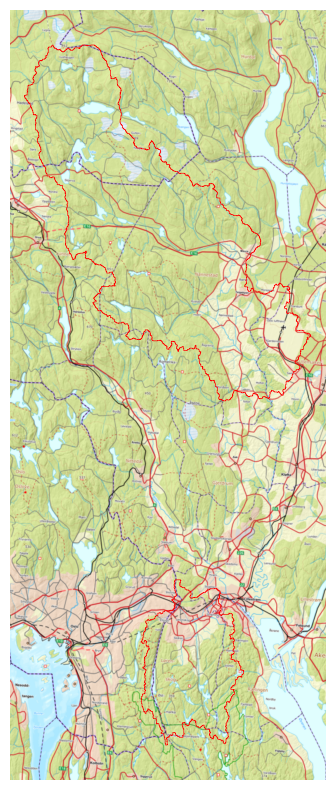

In [13]:
# Plot
ax = nve_cat_gdf.plot(figsize=(10, 10), edgecolor="r", facecolor="none")
cx.add_basemap(
    ax, crs=nve_cat_gdf.crs, source=kartverket, attribution=False
)
ax.set_axis_off()

### 4.2. Data from the GTS API

In [14]:
pars = ["gwb_q"]
max_retries = 5
n_samp = 300
temp_dir = r"/home/jovyan/shared/common/JES/temp"

# Loop over catchments
for stn_id, gdf in nve_cat_gdf.groupby("station_id"):
    # Skip if already processed
    fname = stn_id.replace(".", "-")
    csv_path = os.path.join(temp_dir, f"{fname}.csv")
    if os.path.isfile(csv_path):
        continue
    retries = 0
    while retries < max_retries:
        try:
            cat_area = gdf.iloc[0]["cat_area_km2"]
            stat_df = utils.get_nve_gts_api_aggregated_time_series(
                gdf,
                pars,
                st_dt,
                end_dt,
                id_col="station_id",
                n_samp=n_samp,
                random_state=42,
            )
            stat_df["par"] = "gts_avg_" + stat_df["par"] + "_" + stat_df["unit"]
            stat_df = stat_df.set_index(["datetime", "par"])["value_mean"].unstack(
                "par"
            )
            stat_df.columns.name = ""
            stat_df = stat_df.resample("D").mean()
            stat_df["date"] = stat_df.index
            stat_df = stat_df.reset_index(drop=True)
            stat_df["gts_mod_discharge_m3ps"] = (
                1e6 * cat_area * stat_df["gts_avg_gwb_q_mm"] / (1000 * 24 * 60 * 60)
            )
            stat_df["station_id"] = stn_id
            stat_df = stat_df[["station_id", "date", "gts_mod_discharge_m3ps"]]
            stat_df.to_csv(csv_path, index=False)
            break
        except URLError as e:
            retries += 1
            time.sleep(5)

# Combine all data
flist = glob.glob(os.path.join(temp_dir, "*.csv"))
gts_df = pd.concat([pd.read_csv(fpath) for fpath in flist], axis="rows")
gts_df["date"] = pd.to_datetime(gts_df["date"])
[os.remove(fpath) for fpath in flist]

gts_df.head()

Looping over parameters:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over grid cells:   0%|          | 0/114 [00:00<?, ?it/s]

Looping over parameters:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over grid cells:   0%|          | 0/300 [00:00<?, ?it/s]

,station_id,date,gts_mod_discharge_m3ps
0,2.1185.0,1980-01-01,1.059524
1,2.1185.0,1980-01-02,0.979977
2,2.1185.0,1980-01-03,0.902639
3,2.1185.0,1980-01-04,0.844084
4,2.1185.0,1980-01-05,0.806520


### 4.3. Compare

In [15]:
comp_df = pd.merge(nve_df, gts_df, how="inner", on=["station_id", "date"])
comp_df.head()

,station_id,station_name,date,nve_obs_discharge_m3ps,gts_mod_discharge_m3ps
0,2.279.0,Kråkfoss,1980-01-01,2.591067,1.556485
1,2.279.0,Kråkfoss,1980-01-02,2.591067,1.483317
2,2.279.0,Kråkfoss,1980-01-03,2.456715,1.440081
3,2.279.0,Kråkfoss,1980-01-04,2.456715,1.396845
4,2.279.0,Kråkfoss,1980-01-05,2.456715,1.385205


,station_id,NSE,KGE,Bias,Norm_Bias,RMSD,Norm_RMSD,n
0,2.1185.0,0.510650,0.671147,-0.159123,-0.129041,-1.602578,-0.687531,3284
1,2.279.0,0.612446,0.735480,-0.178468,-0.143762,-6.755460,-0.605711,16433


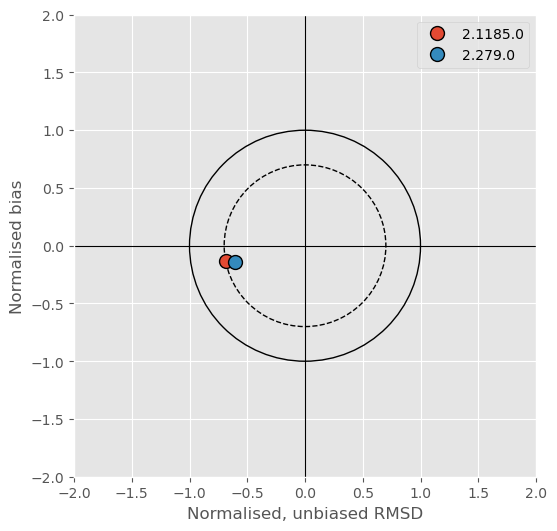

In [16]:
stats.target_plot(
    comp_df,
    "gts_mod_discharge_m3ps",
    "nve_obs_discharge_m3ps",
    group_col="station_id",
    ax=None,
    title=None,
)

display(
    stats.performance_summary(
        comp_df,
        "gts_mod_discharge_m3ps",
        "nve_obs_discharge_m3ps",
        group_col="station_id",
    )
)

#
png_path = r"../plots/nve_target_plot.png"
plt.savefig(png_path, dpi=200, bbox_inches="tight")

<Axes: xlabel='date'>

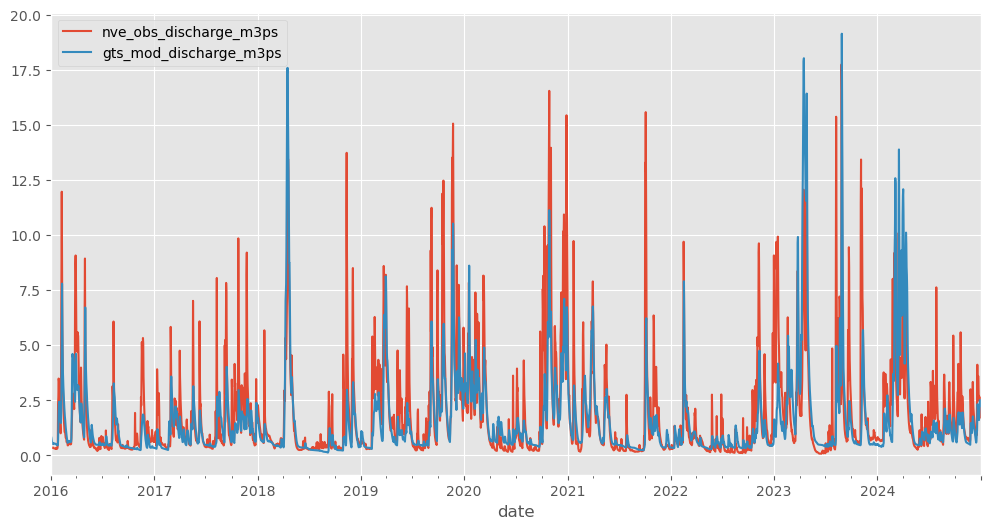

In [17]:
# %matplotlib ipympl

# Plot time series
stn_id = "2.1185.0"
comp_df.query("station_id == @stn_id").set_index("date")[
    ["nve_obs_discharge_m3ps", "gts_mod_discharge_m3ps"]
].plot(figsize=(12, 6))

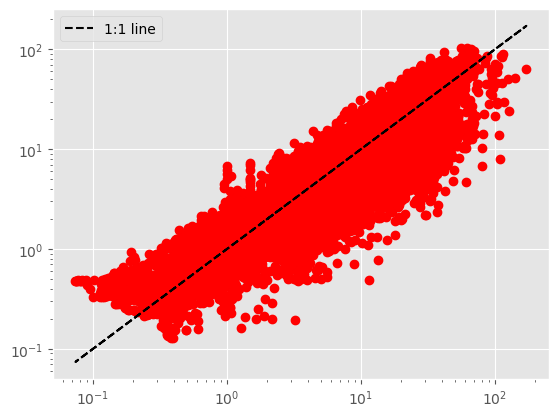

In [18]:
plt.plot(comp_df["nve_obs_discharge_m3ps"], comp_df["gts_mod_discharge_m3ps"], "ro")
plt.plot(
    comp_df["nve_obs_discharge_m3ps"],
    comp_df["nve_obs_discharge_m3ps"],
    "k--",
    label="1:1 line",
)
plt.legend()
plt.xscale("log")
plt.yscale("log")

### 4.4. Catchment boundaries for chemistry stations

In [19]:
# 'vm_stn_df' currently has all Vannmiljø stations linked to the waterbodies.
# Check that this also includes the stations specified by Jan Erik and Kristian,
# to be sure we get all required flow data
assert set(stn_df["station_id"]).issubset(set(vm_stn_df["station_code"]))

In [20]:
vm_cat_gdf = nivapy.spatial.derive_watershed_boundaries(
    vm_stn_df,
    id_col="station_id",
    xcol="utm33_east",
    ycol="utm33_north",
    crs="epsg:25833",
    min_size_km2=10,
    dem_res_m=40,
    buffer_km=None,
    temp_fold=None,
    reproject=False,
)
vm_cat_gdf["cat_area_km2"] = vm_cat_gdf.to_crs({"proj": "cea"}).geometry.area / 1e6

# Save
vm_cat_gdf.drop(columns="geometry").to_excel(
    r"../data/vannmiljo_catch_metadata.xlsx", index=False
)

vm_cat_gdf

Connection successful.


Looping over vassdragsområder:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over outlets in vassdragsområder 002:   0%|          | 0/73 [00:00<?, ?it/s]

,station_id,geometry,station_code,station_name,feature_type,category,fylke_id,fylke_name,kommune_id,kommune_name,...,vassom_name,vannom_id,vannom_name,vannreg_id,vannreg_name,waterbody_id,waterbody_name,utm33_east,utm33_north,cat_area_km2
0,28251,"POLYGON ((255960 6689560, 255960 6689480, 2558...",002-28251,Nitelva ved Åmot,point,R,32,Akershus,3205,Lillestrøm,...,Glommavassdraget/Hvaler og Singlefjorden,5110-10,Leira - Nitelva,5110,Glomma,002-3891-R,Nedre Nitelva,280231.9011,6.651353e+06,483.683336
1,28253,"POLYGON ((255960 6689560, 255960 6689480, 2558...",002-28253,Nitelva ved Nitelva bru,point,R,32,Akershus,3205,Lillestrøm,...,Glommavassdraget/Hvaler og Singlefjorden,5110-10,Leira - Nitelva,5110,Glomma,002-3891-R,Nedre Nitelva,278294.1993,6.653250e+06,476.756471
2,28260,"MULTIPOLYGON (((270920 6698040, 270920 6698000...",002-28260,Leira ved Frogner,point,R,32,Akershus,3205,Lillestrøm,...,Glommavassdraget/Hvaler og Singlefjorden,5110-10,Leira - Nitelva,5110,Glomma,002-3384-R,Leira nedstrøms Krokfoss,282600.0603,6.660597e+06,616.441866
3,28960,"MULTIPOLYGON (((291400 6657720, 291360 6657720...",002-28960,Rømua ved Lørenfallet - RØM1,point,R,32,Akershus,3205,Lillestrøm,...,Glommavassdraget/Hvaler og Singlefjorden,5110-07,Øyeren,5110,Glomma,002-3659-R,Rømua,289429.5000,6.659838e+06,201.696987
4,28964,"POLYGON ((255960 6689560, 255960 6689480, 2558...",002-28964,Nitelva ved Åros bru,point,R,32,Akershus,3205,Lillestrøm,...,Glommavassdraget/Hvaler og Singlefjorden,5110-10,Leira - Nitelva,5110,Glomma,002-1638-R,Nitelva Slattum-Kjeller,275712.9351,6.656818e+06,320.741642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,125320,"MULTIPOLYGON (((291400 6657720, 291360 6657720...",002-125320,A4-22 Overvannsrør ved RØM1,point,R,32,Akershus,3205,Lillestrøm,...,Glommavassdraget/Hvaler og Singlefjorden,5110-07,Øyeren,5110,Glomma,002-3659-R,Rømua,289447.0000,6.659799e+06,201.708183
69,125322,"POLYGON ((293080 6685000, 293080 6684880, 2931...",002-125322,8 Rømua oppstrøms Asakbekken ved Asakenga/hest...,point,R,32,Akershus,3205,Lillestrøm,...,Glommavassdraget/Hvaler og Singlefjorden,5110-07,Øyeren,5110,Glomma,002-3659-R,Rømua,289592.0000,6.661539e+06,168.826634
70,125505,"POLYGON ((296320 6655280, 296320 6655240, 2962...",002-125505,KAU,point,R,32,Akershus,3205,Lillestrøm,...,Glommavassdraget/Hvaler og Singlefjorden,5110-07,Øyeren,5110,Glomma,002-3692-R,Stensrudåa - Korsåa,296284.0000,6.655258e+06,56.793560
71,126657,"POLYGON ((255960 6689560, 255960 6689480, 2558...",002-126657,Nitelva oppstrøms Ringnes,point,R,32,Akershus,3232,Nittedal,...,Glommavassdraget/Hvaler og Singlefjorden,5110-10,Leira - Nitelva,5110,Glomma,002-1638-R,Nitelva Slattum-Kjeller,273611.3155,6.658039e+06,315.671914


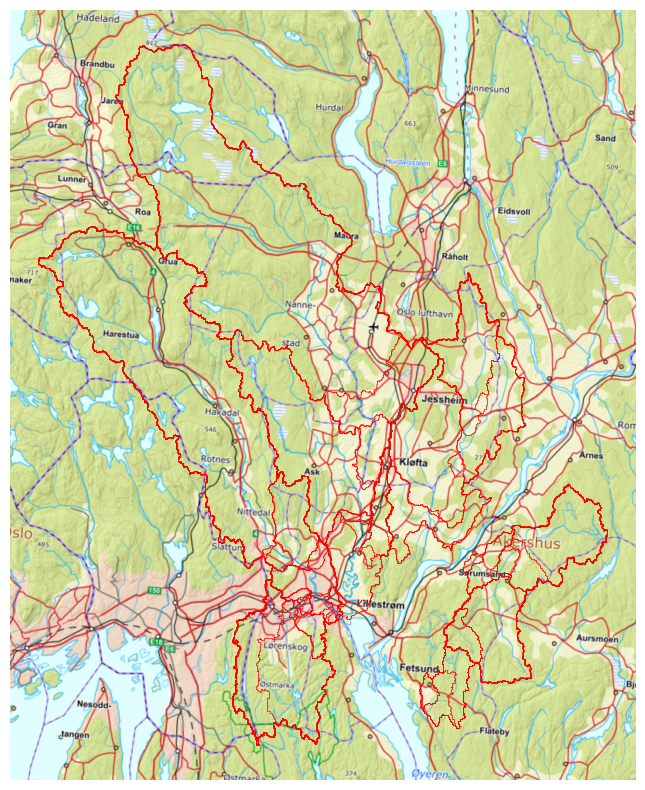

In [21]:
# Plot
ax = vm_cat_gdf.plot(figsize=(10, 10), edgecolor="r", facecolor="none")
cx.add_basemap(
    ax, crs=vm_cat_gdf.crs, source=kartverket, attribution=False
)
ax.set_axis_off()

### 4.5. GTS data for chemistry stations

In [ ]:
pars = ["gwb_q"]
max_retries = 5
n_samp = 300
temp_dir = r"/home/jovyan/shared/common/JES/test"

# Loop over catchments
for stn_id, gdf in vm_cat_gdf.groupby("station_code"):
    # Skip if already processed
    fname = stn_id.replace(".", "-")
    csv_path = os.path.join(temp_dir, f"{fname}.csv")
    if os.path.isfile(csv_path):
        continue
    retries = 0
    while retries < max_retries:
        try:
            cat_area = gdf.iloc[0]["cat_area_km2"]
            stat_df = utils.get_nve_gts_api_aggregated_time_series(
                gdf,
                pars,
                st_dt,
                end_dt,
                id_col="station_code",
                n_samp=n_samp,
                random_state=42,
            )
            stat_df["par"] = "gts_avg_" + stat_df["par"] + "_" + stat_df["unit"]
            stat_df = stat_df.set_index(["datetime", "par"])["value_mean"].unstack(
                "par"
            )
            stat_df.columns.name = ""
            stat_df = stat_df.resample("D").mean()
            stat_df["date"] = stat_df.index
            stat_df = stat_df.reset_index(drop=True)
            stat_df["gts_mod_discharge_m3ps"] = (
                1e6 * cat_area * stat_df["gts_avg_gwb_q_mm"] / (1000 * 24 * 60 * 60)
            )
            stat_df["station_code"] = stn_id
            stat_df = stat_df[["station_code", "date", "gts_mod_discharge_m3ps"]]
            stat_df.to_csv(csv_path, index=False)
            break
        except URLError as e:
            retries += 1
            time.sleep(5)

# Combine all data
flist = glob.glob(os.path.join(temp_dir, "*.csv"))
gts_df = pd.concat([pd.read_csv(fpath) for fpath in flist], axis="rows")
gts_df["date"] = pd.to_datetime(gts_df["date"])
[os.remove(fpath) for fpath in flist]

# Reshape
gts_df = gts_df.pivot(
    index="date", columns="station_code", values="gts_mod_discharge_m3ps"
).reset_index()
gts_df.columns.name = ""

# Save
nve_xl_path = r"../data/nve_data.xlsx"
with pd.ExcelWriter(nve_xl_path) as writer:
    nve_df.to_excel(writer, sheet_name="hyd-api", index=False)
    gts_df.to_excel(writer, sheet_name="gts-api", index=False)

gts_df.head()

Looping over parameters:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over grid cells:   0%|          | 0/101 [00:00<?, ?it/s]

Looping over parameters:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over grid cells:   0%|          | 0/26 [00:00<?, ?it/s]

Looping over parameters:   0%|          | 0/1 [00:00<?, ?it/s]

...

Looping over grid cells:   0%|          | 0/110 [00:00<?, ?it/s]

Looping over parameters:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over grid cells:   0%|          | 0/300 [00:00<?, ?it/s]

Looping over parameters:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over grid cells:   0%|          | 0/300 [00:00<?, ?it/s]